# 2026 AI Job Market Analysis

This notebook analyzes a final cleaned AI job market dataset.

The heavy processing steps were completed in a previous notebook:

- job title normalization
- ESCO occupation mapping
- skill inference
- local LLM validation
- final recommended skill selection

The goal of this notebook is simpler: create clear market insights with clean tables and visualizations.

## 1. Import Libraries

We use common Python libraries for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import ast

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Define Project Paths

The dataset is stored in the project folder. We also create folders for figures and tables.

In [2]:
DATA_DIR = Path(
    r"C:\Users\jerem\job_analysis\2026_ai_job_market_analysis"
)

DATASET_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "final_ai_job_market_dataset.csv"
)

OUTPUT_DIR = DATA_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATASET_PATH)
print("Figure folder:", FIGURE_DIR)
print("Table folder:", TABLE_DIR)

Dataset path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\final_ai_job_market_dataset.csv
Figure folder: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures
Table folder: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\tables


## 3. Helper Functions

Only three small helper functions are used to keep the notebook readable.

In [3]:
def parse_list_column(value):
    """Convert a list stored as text into a real Python list."""
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    try:
        parsed_value = ast.literal_eval(str(value))
        if isinstance(parsed_value, list):
            return [str(item).strip().lower() for item in parsed_value if str(item).strip()]
    except Exception:
        pass
    return []


def clean_text_category(value, unknown_label="Unknown"):
    """Clean a categorical text value and replace missing values with Unknown."""
    if pd.isna(value):
        return unknown_label
    value = str(value).strip()
    if value == "" or value.lower() in ["nan", "none", "null"]:
        return unknown_label
    return value


def save_figure(filename):
    """Save the current matplotlib figure in the figures folder."""
    output_path = FIGURE_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print("Figure saved:", output_path)

## 4. Load Dataset

We keep `df_raw` unchanged and use `df_analysis` as the working dataframe.

In [4]:
df_raw = pd.read_csv(DATASET_PATH)
df_analysis = df_raw.copy()

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)

display(df_raw.head())

Dataset loaded successfully.
Shape: (5773, 48)


,job_posting_id,job_title,job_title_original,company,country,city,city_clean,remote_type,experience_level,source,salary_min,salary_max,salary_avg,currency,posted_date,year,month,year_month,job_description,description_length,description_truncated,normalized_title,title_similarity,normalization_method,esco_occupation,required_skills,original_skills_list,has_original_skills,n_original_skills,inferred_skills_knn,completed_skills_list,skill_inference_method,has_section9_completed_skills,n_section9_completed_skills,needs_llm_validation,llm_status,llm_validated_skills_list,llm_removed_skills_list,llm_skill_reasons,llm_keep_rate,recommended_skills_list,recommended_skills,final_recommended_skills,recommended_skill_source,final_skill_source,has_recommended_skills,n_recommended_skills,n_final_recommended_skills
0,1,AI Engineer,AI Engineer,Jobot,United States,Mount Carmel,mount carmel,Unspecified,Lead,Adzuna,160000.0,160000.0,160000.0,USD,2026-02-16,2026.0,2.0,2026-02,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,['rag'],True,1,[],['rag'],original,True,1,False,not_validated,[],[],{},0.000000,['rag'],rag,rag,original,original,True,1,1
1,2,AI Engineer,AI Engineer,Jobot,United States,The Gap,the gap,Unspecified,Lead,Adzuna,175000.0,175000.0,175000.0,USD,2026-02-16,2026.0,2.0,2026-02,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,['rag'],True,1,[],['rag'],original,True,1,False,not_validated,[],[],{},0.000000,['rag'],rag,rag,original,original,True,1,1
2,3,AI Engineer,AI Engineer,Jobot,United States,Nashville,nashville,Unspecified,Lead,Adzuna,218000.0,218000.0,218000.0,USD,2026-02-16,2026.0,2.0,2026-02,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,['rag'],True,1,[],['rag'],original,True,1,False,not_validated,[],[],{},0.000000,['rag'],rag,rag,original,original,True,1,1
3,4,Frontend/AI Engineer,Frontend/AI Engineer,Jobot,United States,New York City,new york city,Unspecified,Mid-level,Adzuna,112000.0,112000.0,112000.0,USD,2026-02-16,2026.0,2.0,2026-02,Manufacturing Company looking for Business System Analyst This Jobot Job is hosted by: John Erwin Are you a fit? Eas...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,NaN,[],False,0,"['rag', 'aws', 'azure', 'computer vision', 'gcp', 'hadoop', 'nlp', 'python']","['rag', 'aws', 'azure', 'computer vision', 'gcp', 'hadoop', 'nlp', 'python']",knn_inference,True,8,True,ok,"['aws', 'azure', 'computer vision', 'nlp', 'python']","['gcp', 'hadoop', 'rag']",{},0.625000,"['aws', 'azure', 'computer vision', 'nlp', 'python']","aws, azure, computer vision, nlp, python","aws, azure, computer vision, nlp, python",llm_validated_with_rescue,llm_validated_with_rescue,True,5,5
4,5,AI Engineering Lead,AI Engineering Lead,Jobot,United States,Irvine,irvine,Unspecified,Senior,Adzuna,92000.0,92000.0,92000.0,USD,2026-02-16,2026.0,2.0,2026-02,Lead Financial Insights and Reporting as a Senior Accountant in a Dynamic Energy-Focused Environment This Jobot Job ...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,NaN,[],False,0,"['rag', 'fine-tuning', 'azure']","['rag', 'fine-tuning', 'azure']",knn_inference,True,3,True,ok,['azure'],"['fine-tuning', 'rag']",{},0.333333,['azure'],azure,azure,llm_validated_with_rescue,llm_validated_with_rescue,True,1,1


## 5. Create Analysis Dataset

We keep only the columns needed for analysis. The code checks if each column exists before selecting it.

In [5]:
analysis_columns = [
    "job_title", "normalized_title", "esco_occupation", "company", "country", "city",
    "remote_type", "experience_level", "source", "salary_min", "salary_max", "salary_avg",
    "currency", "posted_date", "job_description", "description_truncated",
    "original_skills_list", "completed_skills_list", "llm_validated_skills_list",
    "llm_removed_skills_list", "recommended_skills_list", "recommended_skills",
    "skill_inference_method", "recommended_skill_source", "llm_status", "llm_keep_rate",
    "has_recommended_skills", "n_recommended_skills", "n_original_skills"
]

available_columns = [col for col in analysis_columns if col in df_raw.columns]
missing_columns = [col for col in analysis_columns if col not in df_raw.columns]

df_analysis = df_raw[available_columns].copy()

print("Analysis dataset shape:", df_analysis.shape)
print("Missing optional columns:", missing_columns)

Analysis dataset shape: (5773, 29)
Missing optional columns: []


## 6. Parse Skill List Columns

Skill list columns are converted from text into real Python lists.

In [6]:
list_columns = [
    "original_skills_list",
    "completed_skills_list",
    "llm_validated_skills_list",
    "llm_removed_skills_list",
    "recommended_skills_list"
]

for col in list_columns:
    if col in df_analysis.columns:
        df_analysis[col] = df_analysis[col].apply(parse_list_column)
        print("Parsed:", col)

Parsed: original_skills_list
Parsed: completed_skills_list
Parsed: llm_validated_skills_list
Parsed: llm_removed_skills_list
Parsed: recommended_skills_list


## 7. Clean Categorical, Numeric, and Date Columns

Categorical values are standardized. Salary columns are converted to numeric values. Dates are converted to datetime values.

In [7]:
categorical_columns = [
    "job_title", "normalized_title", "esco_occupation", "company", "country", "city",
    "currency", "remote_type", "experience_level", "source", "skill_inference_method",
    "recommended_skill_source", "llm_status"
]

for col in categorical_columns:
    if col in df_analysis.columns:
        df_analysis[col] = df_analysis[col].apply(clean_text_category)

numeric_columns = [
    "salary_min", "salary_max", "salary_avg", "llm_keep_rate",
    "n_recommended_skills", "n_original_skills"
]

for col in numeric_columns:
    if col in df_analysis.columns:
        df_analysis[col] = pd.to_numeric(df_analysis[col], errors="coerce")

if "posted_date" in df_analysis.columns:
    df_analysis["posted_date"] = pd.to_datetime(df_analysis["posted_date"], errors="coerce")
    df_analysis["posted_month"] = df_analysis["posted_date"].dt.to_period("M").astype(str)

print("Cleaning completed.")

Cleaning completed.


## 8. Create Helper Columns

Helper columns make filtering and coverage analysis easier.

In [8]:
if "salary_avg" in df_analysis.columns:
    df_analysis["has_salary"] = df_analysis["salary_avg"].notna()

if "original_skills_list" in df_analysis.columns:
    df_analysis["n_original_skills"] = df_analysis["original_skills_list"].apply(len)
    df_analysis["has_original_skills"] = df_analysis["n_original_skills"] > 0

if "recommended_skills_list" in df_analysis.columns:
    df_analysis["n_recommended_skills"] = df_analysis["recommended_skills_list"].apply(len)
    df_analysis["has_recommended_skills"] = df_analysis["n_recommended_skills"] > 0

if "remote_type" in df_analysis.columns:
    df_analysis["remote_type_clean"] = (
        df_analysis["remote_type"].str.lower().str.strip()
        .replace({
            "remote": "Remote", "hybrid": "Hybrid", "on-site": "On-site",
            "onsite": "On-site", "on site": "On-site",
            "unspecified": "Unspecified", "unknown": "Unknown"
        })
    )

if "experience_level" in df_analysis.columns:
    df_analysis["experience_level_clean"] = (
        df_analysis["experience_level"].str.lower().str.strip()
        .replace({
            "entry": "Entry", "entry-level": "Entry", "junior": "Junior",
            "mid": "Mid-level", "mid-level": "Mid-level", "senior": "Senior",
            "lead": "Lead", "principal": "Principal", "manager": "Management",
            "management": "Management", "unknown": "Unknown"
        })
    )

print("Helper columns created.")
df_analysis.head()

Helper columns created.


,job_title,normalized_title,esco_occupation,company,country,city,remote_type,experience_level,source,salary_min,salary_max,salary_avg,currency,posted_date,job_description,description_truncated,original_skills_list,completed_skills_list,llm_validated_skills_list,llm_removed_skills_list,recommended_skills_list,recommended_skills,skill_inference_method,recommended_skill_source,llm_status,llm_keep_rate,has_recommended_skills,n_recommended_skills,n_original_skills,posted_month,has_salary,has_original_skills,remote_type_clean,experience_level_clean
0,AI Engineer,AI Engineer,artificial intelligence engineer,Jobot,United States,Mount Carmel,Unspecified,Lead,Adzuna,160000.0,160000.0,160000.0,USD,2026-02-16,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,True,[rag],[rag],[],[],[rag],rag,original,original,not_validated,0.000000,True,1,1,2026-02,True,True,Unspecified,Lead
1,AI Engineer,AI Engineer,artificial intelligence engineer,Jobot,United States,The Gap,Unspecified,Lead,Adzuna,175000.0,175000.0,175000.0,USD,2026-02-16,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,True,[rag],[rag],[],[],[rag],rag,original,original,not_validated,0.000000,True,1,1,2026-02,True,True,Unspecified,Lead
2,AI Engineer,AI Engineer,artificial intelligence engineer,Jobot,United States,Nashville,Unspecified,Lead,Adzuna,218000.0,218000.0,218000.0,USD,2026-02-16,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,True,[rag],[rag],[],[],[rag],rag,original,original,not_validated,0.000000,True,1,1,2026-02,True,True,Unspecified,Lead
3,Frontend/AI Engineer,AI Engineer,artificial intelligence engineer,Jobot,United States,New York City,Unspecified,Mid-level,Adzuna,112000.0,112000.0,112000.0,USD,2026-02-16,Manufacturing Company looking for Business System Analyst This Jobot Job is hosted by: John Erwin Are you a fit? Eas...,True,[],"[rag, aws, azure, computer vision, gcp, hadoop, nlp, python]","[aws, azure, computer vision, nlp, python]","[gcp, hadoop, rag]","[aws, azure, computer vision, nlp, python]","aws, azure, computer vision, nlp, python",knn_inference,llm_validated_with_rescue,ok,0.625000,True,5,0,2026-02,True,False,Unspecified,Mid-level
4,AI Engineering Lead,AI Engineer,artificial intelligence engineer,Jobot,United States,Irvine,Unspecified,Senior,Adzuna,92000.0,92000.0,92000.0,USD,2026-02-16,Lead Financial Insights and Reporting as a Senior Accountant in a Dynamic Energy-Focused Environment This Jobot Job ...,True,[],"[rag, fine-tuning, azure]",[azure],"[fine-tuning, rag]",[azure],azure,knn_inference,llm_validated_with_rescue,ok,0.333333,True,1,0,2026-02,True,False,Unspecified,Senior


## 9. Salary Coverage Analysis

Salary conclusions should only use rows where salary information is available.

In [9]:
salary_coverage = df_analysis["has_salary"].mean() * 100

print("Salary coverage:", round(salary_coverage, 2), "%")
print("Rows with salary:", df_analysis["has_salary"].sum())
print("Total rows:", len(df_analysis))

Salary coverage: 58.24 %
Rows with salary: 3362
Total rows: 5773


In [10]:
coverage_table = pd.DataFrame({
    "metric": [
        "Salary available",
        "Original skills available",
        "Recommended skills available",
        "Remote type known"
    ],
    "coverage_percent": [
        df_analysis["has_salary"].mean() * 100,
        df_analysis["has_original_skills"].mean() * 100 if "has_original_skills" in df_analysis.columns else np.nan,
        df_analysis["has_recommended_skills"].mean() * 100 if "has_recommended_skills" in df_analysis.columns else np.nan,
        (~df_analysis["remote_type_clean"].isin(["Unknown", "Unspecified"])).mean() * 100 if "remote_type_clean" in df_analysis.columns else np.nan
    ]
})

coverage_table["coverage_percent"] = coverage_table["coverage_percent"].round(2)
coverage_table

,metric,coverage_percent
0,Salary available,58.24
1,Original skills available,18.78
2,Recommended skills available,86.58
3,Remote type known,18.34


Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\coverage_by_field.png


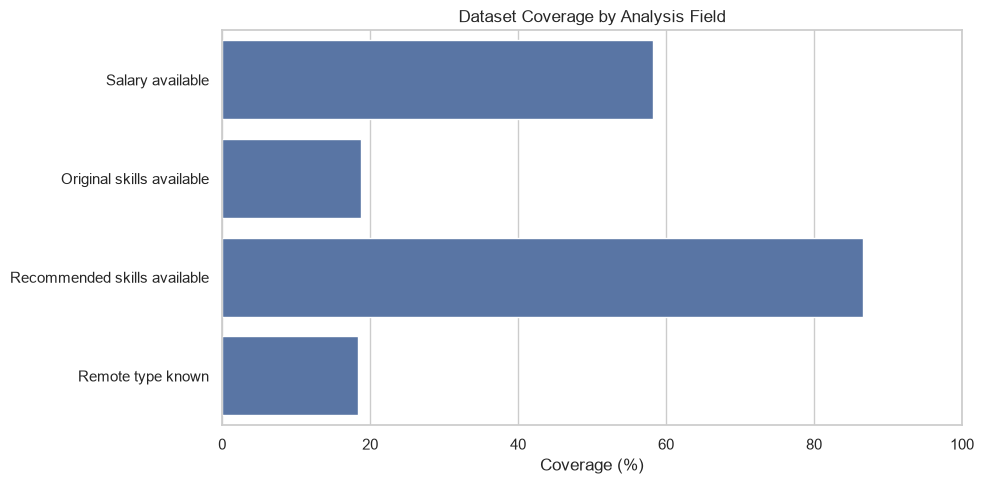

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(data=coverage_table, x="coverage_percent", y="metric")
plt.title("Dataset Coverage by Analysis Field")
plt.xlabel("Coverage (%)")
plt.ylabel("")
plt.xlim(0, 100)
plt.tight_layout()
save_figure("coverage_by_field.png")
plt.show()

## 10. Skill Coverage Analysis

Recommended skills are enriched signals from the previous pipeline. They are useful, but they are not always explicit employer requirements.

In [12]:
skill_summary = pd.DataFrame({
    "metric": [
        "Jobs with original skills",
        "Jobs with recommended skills",
        "Average recommended skills per job"
    ],
    "value": [
        df_analysis["has_original_skills"].sum() if "has_original_skills" in df_analysis.columns else np.nan,
        df_analysis["has_recommended_skills"].sum() if "has_recommended_skills" in df_analysis.columns else np.nan,
        df_analysis["n_recommended_skills"].mean() if "n_recommended_skills" in df_analysis.columns else np.nan
    ]
})

skill_summary

,metric,value
0,Jobs with original skills,1084.000000
1,Jobs with recommended skills,4998.000000
2,Average recommended skills per job,2.454703


## 11. Job Category Analysis

Normalized job categories help compare similar roles even when raw titles differ.

In [13]:
category_counts = df_analysis["normalized_title"].value_counts().reset_index()
category_counts.columns = ["normalized_title", "job_count"]
category_counts.head(15)

,normalized_title,job_count
0,AI Engineer,1329
1,Data Scientist,969
2,Machine Learning Engineer,822
3,Software Engineer,439
4,LLM Engineer,396
5,Research Scientist,382
6,MLOps Engineer,251
7,Computer Vision Engineer,240
8,Product / Management,219
9,Other,166


Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\top_job_categories.png


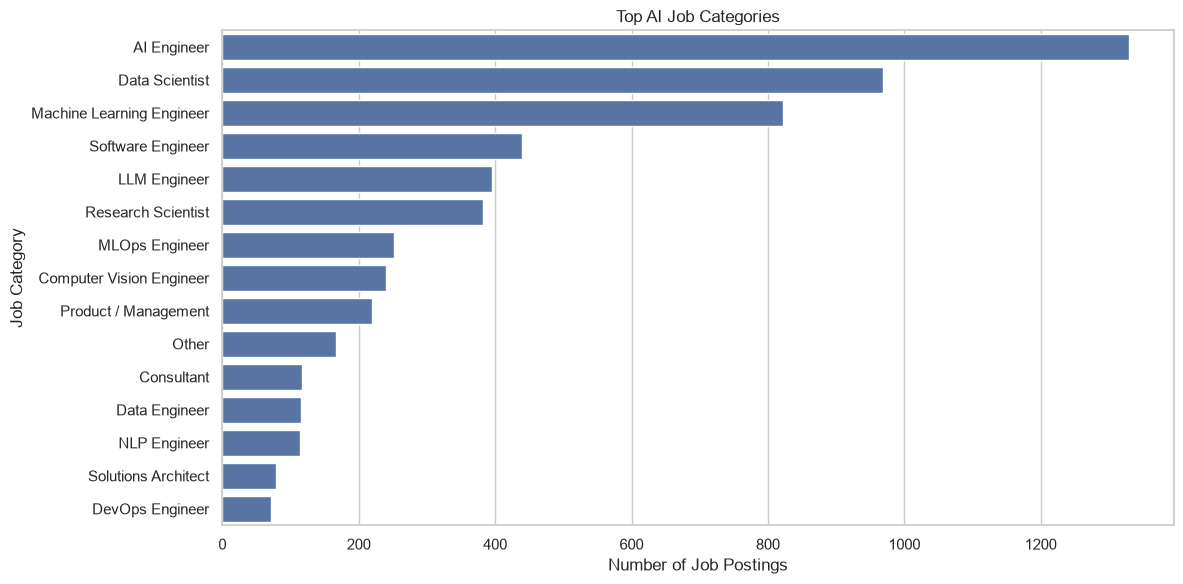

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(data=category_counts.head(15), x="job_count", y="normalized_title")
plt.title("Top AI Job Categories")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Category")
plt.tight_layout()
save_figure("top_job_categories.png")
plt.show()

## 12. Country Analysis

Country analysis shows where postings are located. Salary comparisons across countries should be interpreted carefully.

In [15]:
country_summary = (
    df_analysis
    .groupby("country")
    .agg(
        job_count=("job_title", "count"),
        salary_count=("has_salary", "sum"),
        avg_salary=("salary_avg", "mean"),
        avg_skills_per_job=("n_recommended_skills", "mean")
    )
    .reset_index()
    .sort_values("job_count", ascending=False)
)

country_summary["salary_coverage_percent"] = (
    country_summary["salary_count"] / country_summary["job_count"] * 100
).round(2)

country_summary["avg_salary"] = country_summary["avg_salary"].round(2)
country_summary["avg_skills_per_job"] = country_summary["avg_skills_per_job"].round(2)

country_summary

,country,job_count,salary_count,avg_salary,avg_skills_per_job,salary_coverage_percent
4,United States,1837,1835,133397.55,2.76,99.89
3,United Kingdom,1185,1185,91625.32,2.54,100.00
1,Canada,1068,211,103857.82,2.28,19.76
2,Germany,944,61,88598.36,2.19,6.46
0,Australia,739,70,102835.71,2.16,9.47


Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\job_postings_by_country.png


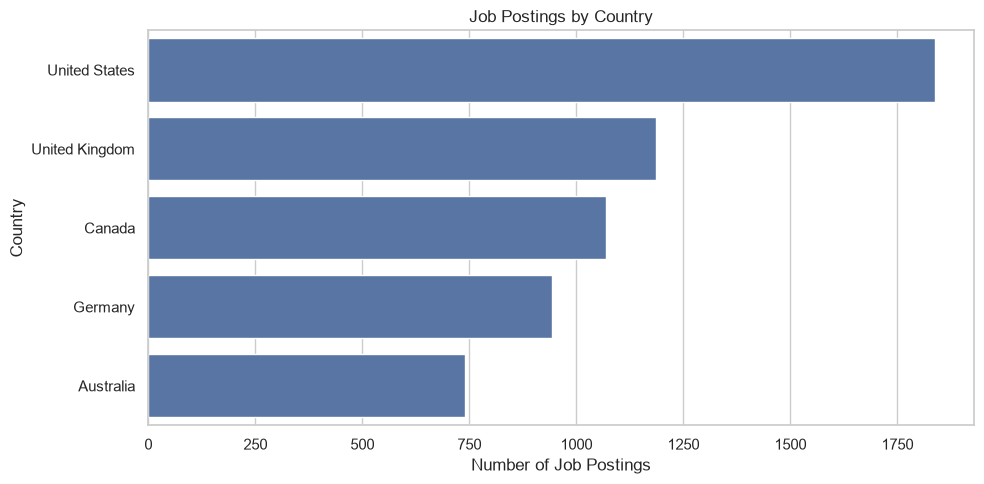

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=country_summary, x="job_count", y="country")
plt.title("Job Postings by Country")
plt.xlabel("Number of Job Postings")
plt.ylabel("Country")
plt.tight_layout()
save_figure("job_postings_by_country.png")
plt.show()

## 13. Salary Analysis

Salary analysis uses only rows where salary data is available. Missing salaries are not imputed.

In [17]:
df_salary = df_analysis[
    df_analysis["has_salary"]
    & (df_analysis["salary_avg"] > 30000)
    & (df_analysis["salary_avg"] < 400000)
].copy()

print("Salary analysis rows:", len(df_salary))
df_salary[["job_title", "normalized_title", "country", "salary_avg", "currency"]].head()

Salary analysis rows: 3341


,job_title,normalized_title,country,salary_avg,currency
0,AI Engineer,AI Engineer,United States,160000.0,USD
1,AI Engineer,AI Engineer,United States,175000.0,USD
2,AI Engineer,AI Engineer,United States,218000.0,USD
3,Frontend/AI Engineer,AI Engineer,United States,112000.0,USD
4,AI Engineering Lead,AI Engineer,United States,92000.0,USD


Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\salary_distribution.png


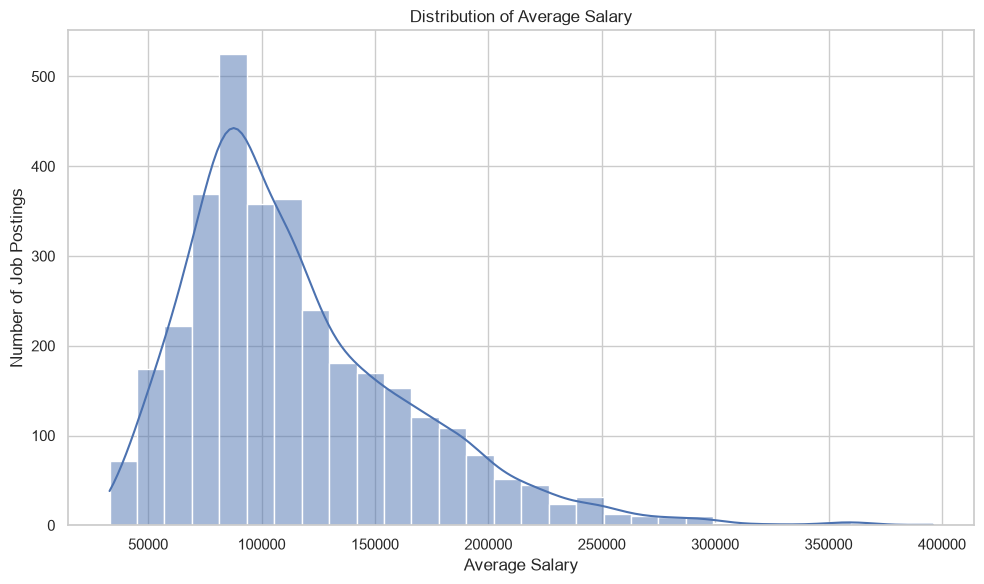

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df_salary["salary_avg"], bins=30, kde=True)
plt.title("Distribution of Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
save_figure("salary_distribution.png")
plt.show()

Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\salary_by_job_category.png


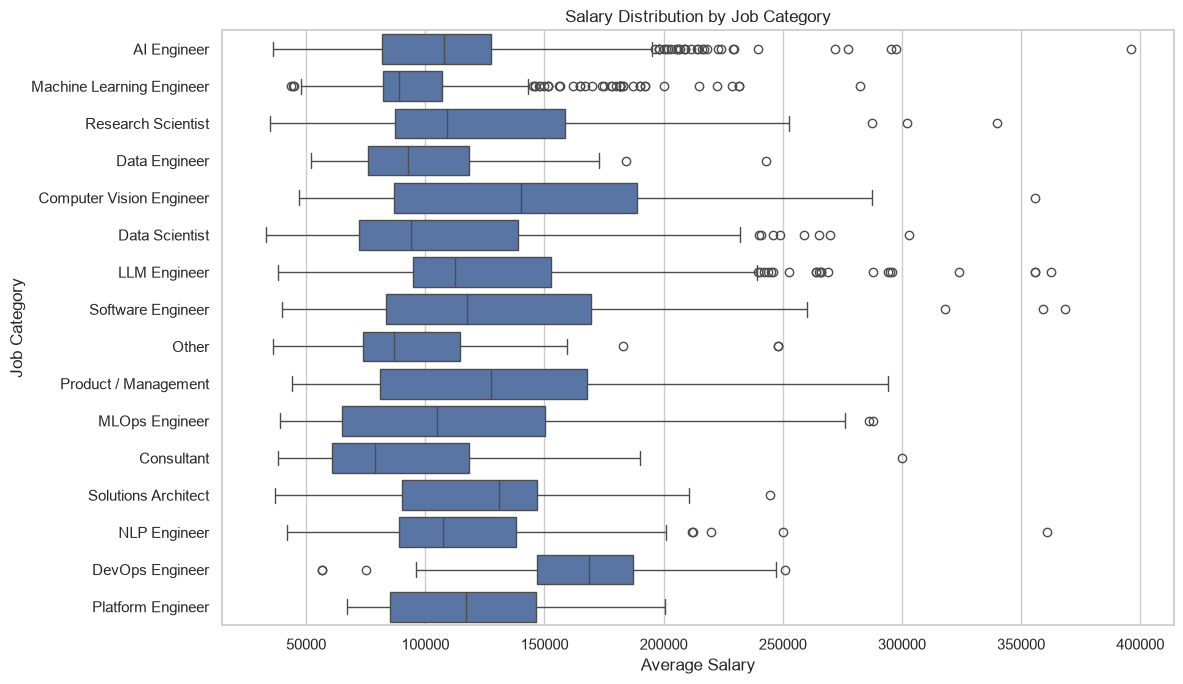

In [19]:
min_rows = 10
valid_categories = df_salary["normalized_title"].value_counts()
valid_categories = valid_categories[valid_categories >= min_rows].index
salary_by_category = df_salary[df_salary["normalized_title"].isin(valid_categories)].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(data=salary_by_category, x="salary_avg", y="normalized_title")
plt.title("Salary Distribution by Job Category")
plt.xlabel("Average Salary")
plt.ylabel("Job Category")
plt.tight_layout()
save_figure("salary_by_job_category.png")
plt.show()

Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\salary_by_experience_level.png


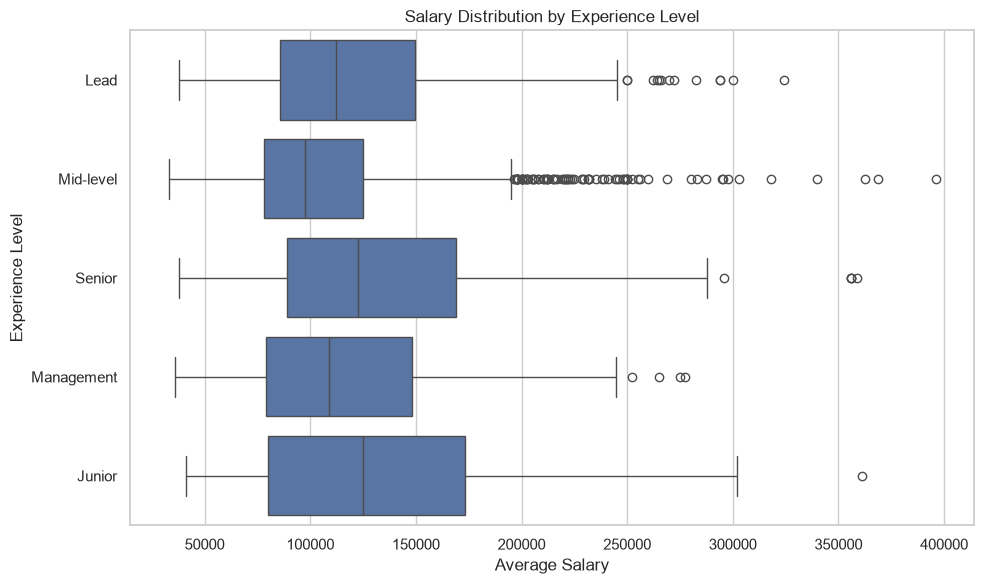

In [20]:
if "experience_level_clean" in df_salary.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_salary, x="salary_avg", y="experience_level_clean")
    plt.title("Salary Distribution by Experience Level")
    plt.xlabel("Average Salary")
    plt.ylabel("Experience Level")
    plt.tight_layout()
    save_figure("salary_by_experience_level.png")
    plt.show()

## 14. Skill Analysis

We create a job-skill table where each row represents one job-skill pair.

In [21]:
skill_columns = [
    "job_title", "normalized_title", "country", "remote_type_clean", "experience_level_clean",
    "recommended_skill_source", "skill_inference_method", "recommended_skills_list"
]
skill_columns = [col for col in skill_columns if col in df_analysis.columns]

df_skills = df_analysis[df_analysis["has_recommended_skills"]][skill_columns].copy()
df_skills = df_skills.explode("recommended_skills_list")
df_skills = df_skills.rename(columns={"recommended_skills_list": "skill"})

df_skills["skill"] = df_skills["skill"].astype(str).str.strip().str.lower()
df_skills = df_skills[df_skills["skill"] != ""].copy()

print("Job-skill rows:", len(df_skills))
print("Unique skills:", df_skills["skill"].nunique())
df_skills.head()

Job-skill rows: 14171
Unique skills: 23


,job_title,normalized_title,country,remote_type_clean,experience_level_clean,recommended_skill_source,skill_inference_method,skill
0,AI Engineer,AI Engineer,United States,Unspecified,Lead,original,original,rag
1,AI Engineer,AI Engineer,United States,Unspecified,Lead,original,original,rag
2,AI Engineer,AI Engineer,United States,Unspecified,Lead,original,original,rag
3,Frontend/AI Engineer,AI Engineer,United States,Unspecified,Mid-level,llm_validated_with_rescue,knn_inference,aws
3,Frontend/AI Engineer,AI Engineer,United States,Unspecified,Mid-level,llm_validated_with_rescue,knn_inference,azure


In [22]:
top_skills = df_skills["skill"].value_counts().reset_index()
top_skills.columns = ["skill", "job_count"]
top_skills.head(20)

,skill,job_count
0,python,2467
1,nlp,1783
2,azure,1480
3,computer vision,1427
4,r,1418
5,aws,1252
6,rag,1193
7,fine-tuning,592
8,openai,446
9,gcp,431


Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\top_recommended_skills.png


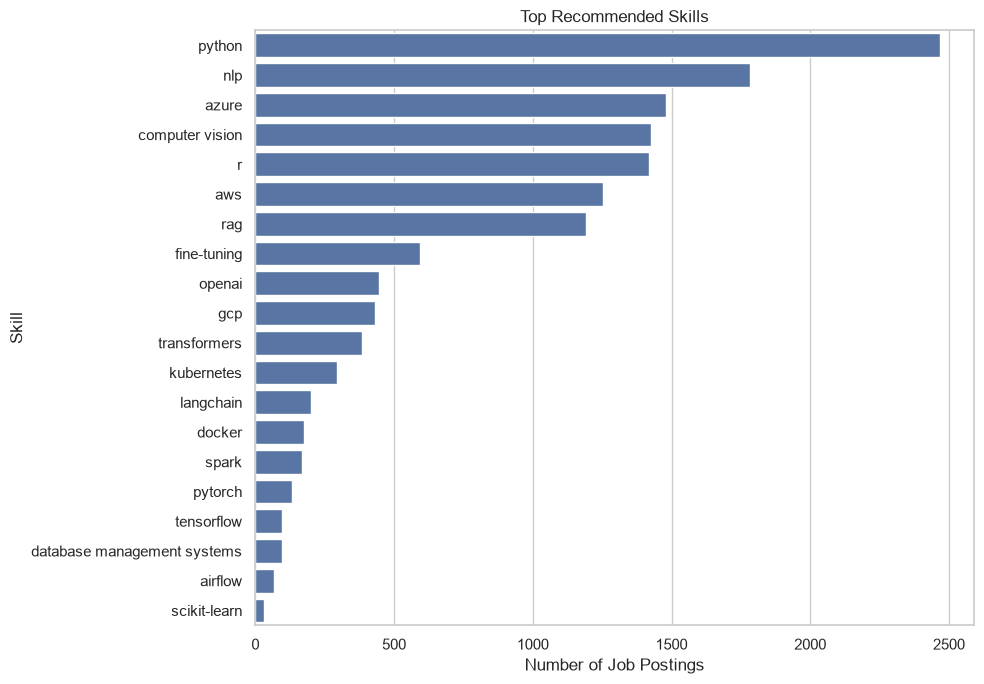

In [23]:
plt.figure(figsize=(10, 7))
sns.barplot(data=top_skills.head(20), x="job_count", y="skill")
plt.title("Top Recommended Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
save_figure("top_recommended_skills.png")
plt.show()

### Top Skills by Job Category

This table shows the most frequent recommended skills for each normalized job category.

In [24]:
top_skills_by_category = (
    df_skills
    .groupby(["normalized_title", "skill"])
    .size()
    .reset_index(name="count")
    .sort_values(["normalized_title", "count"], ascending=[True, False])
)

top_skills_by_category = (
    top_skills_by_category
    .groupby("normalized_title")
    .head(5)
    .reset_index(drop=True)
)

top_skills_by_category.head(30)

,normalized_title,skill,count
0,AI Engineer,python,849
1,AI Engineer,azure,622
2,AI Engineer,nlp,597
3,AI Engineer,rag,499
4,AI Engineer,fine-tuning,346
5,Computer Vision Engineer,computer vision,240
6,Computer Vision Engineer,r,14
7,Computer Vision Engineer,python,13
8,Computer Vision Engineer,fine-tuning,6
9,Computer Vision Engineer,docker,2


## 15. Remote and Experience Analysis

Remote data should be interpreted carefully because many postings may be labeled as `Unspecified`.

,remote_type,job_count
0,Unspecified,4714
1,Remote,576
2,Hybrid,379
3,On-site,104


Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\job_postings_by_remote_type.png


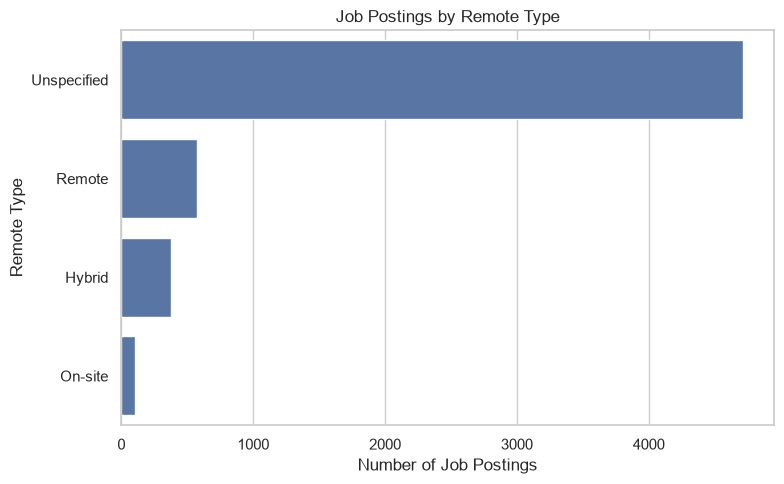

In [25]:
if "remote_type_clean" in df_analysis.columns:
    remote_counts = df_analysis["remote_type_clean"].value_counts().reset_index()
    remote_counts.columns = ["remote_type", "job_count"]
    display(remote_counts)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=remote_counts, x="job_count", y="remote_type")
    plt.title("Job Postings by Remote Type")
    plt.xlabel("Number of Job Postings")
    plt.ylabel("Remote Type")
    plt.tight_layout()
    save_figure("job_postings_by_remote_type.png")
    plt.show()

,experience_level,job_count
0,Mid-level,3264
1,Senior,1470
2,Lead,609
3,Junior,253
4,Management,177


Figure saved: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures\job_postings_by_experience_level.png


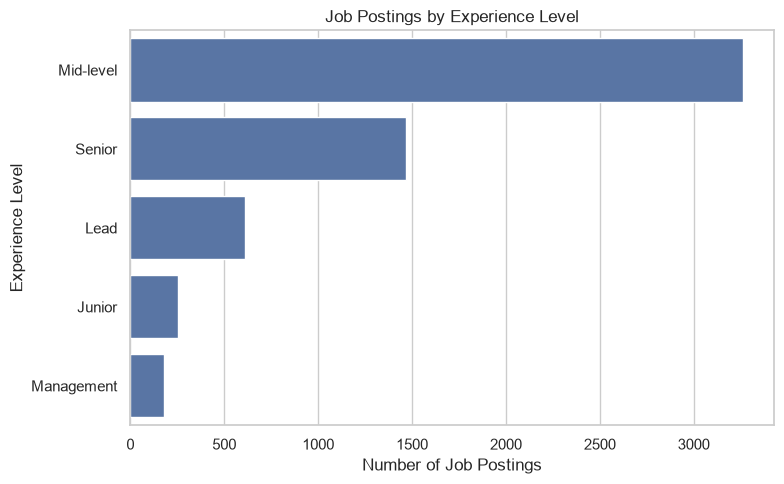

In [26]:
if "experience_level_clean" in df_analysis.columns:
    experience_counts = df_analysis["experience_level_clean"].value_counts().reset_index()
    experience_counts.columns = ["experience_level", "job_count"]
    display(experience_counts)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=experience_counts, x="job_count", y="experience_level")
    plt.title("Job Postings by Experience Level")
    plt.xlabel("Number of Job Postings")
    plt.ylabel("Experience Level")
    plt.tight_layout()
    save_figure("job_postings_by_experience_level.png")
    plt.show()

## 16. Save Cleaned Tables

The main summary tables are saved as CSV files.

In [27]:
df_analysis.to_csv(TABLE_DIR / "analysis_ready_dataset.csv", index=False)
df_salary.to_csv(TABLE_DIR / "salary_analysis_dataset.csv", index=False)
df_skills.to_csv(TABLE_DIR / "skill_analysis_dataset.csv", index=False)

coverage_table.to_csv(TABLE_DIR / "coverage_summary.csv", index=False)
category_counts.to_csv(TABLE_DIR / "job_category_counts.csv", index=False)
country_summary.to_csv(TABLE_DIR / "country_summary.csv", index=False)
top_skills.to_csv(TABLE_DIR / "top_recommended_skills.csv", index=False)
top_skills_by_category.to_csv(TABLE_DIR / "top_skills_by_category.csv", index=False)

print("Tables saved in:", TABLE_DIR)

Tables saved in: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\tables


## 17. Final Interpretation

This notebook provides a simplified market analysis of AI job postings.

### What worked well

The dataset is useful for analyzing:

- the most common AI job categories
- the most frequent recommended skills
- salary coverage
- salary distributions where salary data exists
- country-level job distribution
- remote and experience-level patterns

### Important limitations

The results should be interpreted carefully because:

- salary data is incomplete
- salaries should not be compared across countries without currency normalization
- recommended skills are enriched or inferred signals, not always explicit employer requirements
- job descriptions may be truncated
- some job categories naturally overlap

### Portfolio interpretation

The value of this notebook is not prediction. The value is a clean and transparent data analysis workflow:

1. load a final cleaned dataset
2. prepare analysis-ready tables
3. measure coverage and missingness
4. analyze categories, countries, salaries, and skills
5. create simple professional visualizations
6. save reusable outputs

This is a practical and readable data science workflow that can be presented as part of an AI job market analysis portfolio project.